# 18 · Run a tree inside a ROS node

## Learning objectives

- Use the Jazzy py_trees_ros tree wrapper.
- Schedule nonblocking ticks and consume a topic through a blackboard.
- Separate tree lifecycle from ROS managed-node lifecycle.

**Environment:** ROS 2 Jazzy, sourced workspace, and the ROS notebook kernel from the README. Every ROS example owns and closes its context; run cells in order. Do not call `rclpy.spin` on nodes already managed by `RosSession`.

## Intuition

`py_trees_ros` adds ROS resources, tree snapshots, and blackboard inspection to `py_trees`.
On Jazzy we use the packaged 2.6.0 API: `BehaviourTree.setup(node=..., timeout=...)`,
`tick_tock(period_ms=...)`, and `shutdown(destroy_node=False)`. These are checked against
the Jazzy package, not assumed from ROS 1 examples.

A ROS timer can request ticks periodically. The executor dispatches that timer alongside
subscription callbacks. Each leaf must return promptly so the callbacks that finish its work
can run. A blackboard remains local Python memory; a subscription copies topic data into it.

In [1]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display
from behavior_trees_tutorial.ros_nodes.session import RosSession
from uuid import uuid4
import py_trees_ros
from std_msgs.msg import Bool
from time import monotonic

## Minimal working example
We create a publisher node and a controller node. The controller records a timestamp with
each observation. Its condition rejects missing or stale data. The tick timer starts only
after the first observation, so an initial absence is not mistaken for a sensor fault.

['RUNNING', 'RUNNING', 'SUCCESS'] Blackboard: (True, 8885.323970749)


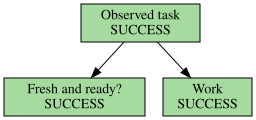

In [2]:
with RosSession() as ros:
    namespace = "/lesson18_" + uuid4().hex
    sensor = ros.node("sensor", namespace=namespace)
    controller = ros.node("controller", namespace=namespace)
    board = pt.blackboard.Client(name="ROS observations", namespace=namespace)
    board.register_key("sample", access=pt.common.Access.WRITE)
    board.sample = (False, 0.0)
    subscription = controller.create_subscription(
        Bool, "ready", lambda message: setattr(board, "sample", (message.data, monotonic())), 10)
    publisher = sensor.create_publisher(Bool, "ready", 10)
    heartbeat = sensor.create_timer(0.05, lambda: publisher.publish(Bool(data=True)))

    def fresh_and_ready():
        ready, timestamp = board.sample
        return Status.SUCCESS if ready and monotonic() - timestamp < 0.5 else Status.FAILURE

    root = pt.composites.Sequence("Observed task", memory=False, children=[
        Function("Fresh and ready?", fresh_and_ready), CountTicks("Work", ticks=3)])
    tree = py_trees_ros.trees.BehaviourTree(root)
    try:
        tree.setup(node=controller, timeout=5.0)
        ros.wait(lambda: board.sample[0])
        statuses = []
        tree.tick_tock(period_ms=50, number_of_iterations=3,
                       post_tick_handler=lambda tree: statuses.append(tree.root.status.name))
        ros.wait(lambda: len(statuses) == 3)
        assert statuses == ["RUNNING", "RUNNING", "SUCCESS"]
        print(statuses, "Blackboard:", board.sample)
        display(diagram(root))
    finally:
        tree.shutdown(destroy_node=False)  # RosSession owns the controller node.
        board.unregister_all_keys()

## Step-by-step implementation
The subscription stores one `(value, timestamp)` tuple; the condition reads one snapshot.
The controller's default mutually exclusive callback group keeps its timer and subscription
callbacks from overlapping. If you later introduce reentrant groups or multiple writers,
add an explicit synchronization policy.

The tree lifecycle is setup → repeated tick → interrupt/stop → shutdown. A ROS **managed
lifecycle node** adds configure, activate, deactivate, and cleanup states. We use ordinary
nodes here, not `LifecycleNode`. In a managed application, setup belongs near configure,
the tick timer starts at activate, deactivate stops ticking and cancels active goals, and
cleanup destroys resources. Shutting down a tree is not a substitute for requesting action
cancellation while the executor is still alive.

In [3]:
# Standalone comparison: the same three updates produce the same outcomes.
standalone = CountTicks("Work", ticks=3)
observed = [row["Work"] for row in trace(standalone, 3)]
assert observed == statuses

1 Work: RUNNING
2 Work: RUNNING
3 Work: SUCCESS


## Interactive demonstration
The local copy makes lifecycle exploration safe after the ROS context has closed. Reset
invalidates the old tree before creating a fresh one. Use the earlier cell to repeat timer-based execution.

In [4]:
display(playground(lambda: CountTicks("Work", ticks=3)))

## Key observations

Exactly one owner should tick a tree. Do not manually tick it while its ROS tick timer is active. Every resource has one cleanup owner.

## Exercises

1. Stop the sensor heartbeat and tick after 0.5 seconds.
2. Change the timer period without changing the required tick count.
3. Explain which lifecycle transition should cancel a navigation goal.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 18).

## Summary

ROS changes where observations come from and when ticks occur. It does not change SUCCESS, FAILURE, or RUNNING.